<a href="https://colab.research.google.com/github/vixotito67/Notebook-default-of-credit-card-clients/blob/main/Portafolio_Default_Credit_Card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo de Portafolio Semestral
## Réplica y extensión de un paper de Machine Learning

**Paper:** Yeh, I.-C., & Lien, C.-H. (2009). *The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients.* Expert Systems with Applications, 36(2), 2473-2480.

**Curso:** Ciencia de Datos para la Economía
**Integrantes:** Vicente Lagos y Vicente San Martín

Este cuaderno replica el estudio de Yeh y Lien (2009) sobre predicción de la probabilidad de incumplimiento (*default*) de clientes de tarjetas de crédito, implementa un subconjunto representativo de los modelos del paper, propone un modelo adicional (Random Forest) y compara el desempeño de todos ellos con las métricas del paper.


## 1. Resumen del paper

**Pregunta de investigación.** Desde la perspectiva de la gestión del riesgo crediticio, estimar la *probabilidad real* de incumplimiento es más valioso que solo clasificar a un cliente como buen o mal pagador. Los autores se preguntan: (1) ¿existen diferencias de precisión de clasificación entre distintas técnicas de minería de datos?, y (2) ¿la probabilidad de default estimada por esas técnicas representa la probabilidad real de default?

**Datos.** Registros de pago de octubre de 2005 de un banco emisor de tarjetas en Taiwán. El paper usa 25.000 observaciones; el conjunto público en el UCI Machine Learning Repository contiene 30.000 clientes. Cada cliente tiene 23 variables explicativas: monto de crédito otorgado, variables demográficas (sexo, educación, estado civil, edad), el historial de pagos de los últimos seis meses (variables PAY), el monto de los estados de cuenta (BILL_AMT) y el monto de los pagos previos (PAY_AMT). La variable objetivo es binaria: incumplimiento del pago el mes siguiente (1) o no (0).

**Metodología.** Se comparan seis técnicas: K vecinos más cercanos (KNN), regresión logística (LR), análisis discriminante (DA), clasificador Naive Bayes (NB), redes neuronales artificiales (ANN) y árboles de clasificación (CT). La clasificación se evalúa con la tasa de error y con el *area ratio* del lift chart (más sensible cuando las clases están desbalanceadas). Para la probabilidad, proponen el **Sorting Smoothing Method (SSM)**: se ordenan los datos de validación por probabilidad predicha y se estima la probabilidad real como el promedio de la variable objetivo en una ventana de tamaño 2n+1 alrededor de cada punto. Luego se ajusta una regresión lineal (Y = A + BX) entre la probabilidad real (Y) y la predicha (X). Un modelo estima bien la probabilidad real si su R² es cercano a 1, su intercepto A cercano a 0 y su pendiente B cercana a 1.

**Resultados y conclusión.** Las redes neuronales artificiales son el mejor modelo. En clasificación obtienen la mayor *area ratio* en validación (0.54). En la estimación de probabilidad, la ANN alcanza R² = 0.965, A = 0.0145 y B = 0.998, siendo la única técnica cuya probabilidad predicha representa fielmente la probabilidad real de default.

**Justificación de la elección del paper.** Es un estudio clásico y muy citado de riesgo crediticio, un problema central en economía y finanzas. Usa datos abiertos del UCI, aplica varios modelos de clasificación que se vieron en el curso y aporta una idea metodológica interesante (evaluar la calidad de la probabilidad estimada, no solo la clasificación), lo que lo hace ideal para replicar y extender.


## 2. Datos

### 2.1 Obtención de los datos

Los datos provienen del *Default of Credit Card Clients Dataset* del UCI Machine Learning Repository (id = 350). Se descargan directamente con el paquete ucimlrepo.


In [ ]:
# Instalar el paquete de acceso al UCI
try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ucimlrepo'])
    from ucimlrepo import fetch_ucirepo


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, RocCurveDisplay)

from warnings import filterwarnings
filterwarnings('ignore')
sns.set_style('whitegrid')
pd.options.display.float_format = '{:.4f}'.format


In [ ]:
# Descargar el conjunto de datos desde el UCI
fuente = fetch_ucirepo(id=350)
X_raw = fuente.data.features.copy()
y_raw = fuente.data.targets.copy()

# Renombrar las 23 variables (X1..X23 del paper) a nombres legibles
nombres = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
           'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
           'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
           'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
X_raw.columns = nombres

df = X_raw.copy()
df['default'] = y_raw.iloc[:, 0].values
print('Dimensiones:', df.shape)
df.head()


Dimensiones: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### 2.2 Descripción de las variables

| Variable | Descripción |
|---|---|
| LIMIT_BAL | Monto de crédito otorgado (dólar taiwanés) |
| SEX | Sexo (1 = hombre, 2 = mujer) |
| EDUCATION | Educación (1 = posgrado, 2 = universidad, 3 = secundaria, 4 = otros) |
| MARRIAGE | Estado civil (1 = casado, 2 = soltero, 3 = otros) |
| AGE | Edad (años) |
| PAY_1 ... PAY_6 | Estado del pago de septiembre a abril de 2005 (-1 = al día, 1 = atraso de un mes, ..., 9 = atraso de nueve meses o más) |
| BILL_AMT1 ... BILL_AMT6 | Monto del estado de cuenta de septiembre a abril |
| PAY_AMT1 ... PAY_AMT6 | Monto pagado de septiembre a abril |
| default | Incumplimiento del pago el mes siguiente (1 = sí, 0 = no) |


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_1      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

In [ ]:
# Estadísticas descriptivas
df.describe()


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,...,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000
mean,167484.3227,1.6037,1.8531,1.5519,35.4855,-0.0167,-0.1338,-0.1662,-0.2207,-0.2662,...,43262.9490,40311.4010,38871.7604,5663.5805,5921.1635,5225.6815,4826.0769,4799.3876,5215.5026,0.2212
std,129747.6616,0.4891,0.7903,0.5220,9.2179,1.1238,1.1972,1.1969,1.1691,1.1332,...,64332.8561,60797.1558,59554.1075,16563.2804,23040.8704,17606.9615,15666.1597,15278.3057,17777.4658,0.4151
min,10000.0000,1.0000,0.0000,0.0000,21.0000,-2.0000,-2.0000,-2.0000,-2.0000,-2.0000,...,-170000.0000,-81334.0000,-339603.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,50000.0000,1.0000,1.0000,1.0000,28.0000,-1.0000,-1.0000,-1.0000,-1.0000,-1.0000,...,2326.7500,1763.0000,1256.0000,1000.0000,833.0000,390.0000,296.0000,252.5000,117.7500,0.0000
50%,140000.0000,2.0000,2.0000,2.0000,34.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,19052.0000,18104.5000,17071.0000,2100.0000,2009.0000,1800.0000,1500.0000,1500.0000,1500.0000,0.0000
75%,240000.0000,2.0000,2.0000,2.0000,41.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,54506.0000,50190.5000,49198.2500,5006.0000,5000.0000,4505.0000,4013.2500,4031.5000,4000.0000,0.0000
max,1000000.0000,2.0000,6.0000,3.0000,79.0000,8.0000,8.0000,8.0000,8.0000,8.0000,...,891586.0000,927171.0000,961664.0000,873552.0000,1684259.0000,896040.0000,621000.0000,426529.0000,528666.0000,1.0000


In [ ]:
# Valores faltantes
print('Total de valores faltantes:', df.isnull().sum().sum())


Total de valores faltantes: 0


### Verificación de duplicados

Antes de seguir explorando, conviene revisar si hay filas repetidas.


In [ ]:
# Verificar filas duplicadas
print('Filas duplicadas:', df.duplicated().sum())


Filas duplicadas: 35


Se encuentran 35 pares de filas idénticas. Antes de decidir si son errores de carga o clientes distintos, se revisa el identificador de cliente (ID), que viene en los datos pero no se había usado como variable.


In [ ]:
# El identificador de cliente no se usa como variable predictiva, pero sirve para verificar los duplicados
ids = fuente.data.ids
print('IDs únicos:', ids['ID'].nunique(), 'de', len(ids), 'filas')
print('IDs duplicados:', ids['ID'].duplicated().sum())


IDs únicos: 30000 de 30000 filas
IDs duplicados: 0


In [ ]:
# DataFrame con el ID visible junto a las variables, para ver los pares duplicados completos
df_con_id = pd.concat([ids, df], axis=1)

dup_mask = df.duplicated(keep=False)
df_con_id[dup_mask].sort_values(by=list(df.columns))

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
12430,12431,20000,1,2,2,24,2,2,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
14294,14295,20000,1,2,2,24,2,2,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
1759,1760,50000,1,2,2,26,1,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
10250,10251,50000,1,2,2,26,1,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
7170,7171,50000,2,1,2,23,1,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27966,27967,360000,2,1,2,27,1,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
18325,18326,360000,2,1,2,29,1,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
22162,22163,360000,2,1,2,29,1,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
839,840,500000,1,1,1,43,1,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,1


Los 30.000 ID son únicos: el propio dataset trata estas filas como clientes distintos, no como errores de carga. Se revisa el contenido de esas filas para entender por qué coinciden.


In [ ]:
# Inspeccionar el contenido de las filas duplicadas
dup_mask = df.duplicated(keep=False)
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
pay_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
sin_actividad = (df.loc[dup_mask, bill_cols + pay_cols] == 0).all(axis=1)
print(f'Filas duplicadas sin actividad (todos los montos en cero): {sin_actividad.mean():.1%}')
df[dup_mask].sort_values('LIMIT_BAL').head(6)


Filas duplicadas sin actividad (todos los montos en cero): 85.7%


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
12430,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
14294,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
7170,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
1759,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
17032,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
10250,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0


La mayoría de las filas duplicadas corresponde a cuentas sin actividad (PAY_1 = -2, todos los montos en cero) con un límite de crédito de catálogo (20.000, 50.000...); el resto son cuentas con un único cargo fijo mensual pagado siempre completo. Son perfiles simples que dos clientes distintos pueden compartir por coincidencia, no errores de carga. **Se mantienen las 30.000 filas.**


In [ ]:
# Distribución de la variable objetivo
conteo = df['default'].value_counts().sort_index()
print(conteo)
print(f"\nProporción de clientes en default: {df['default'].mean():.2%}")


default
0    23364
1     6636
Name: count, dtype: int64

Proporción de clientes en default: 22.12%


### 2.3 Análisis exploratorio

El problema está desbalanceado: alrededor del 22% de los clientes cae en default. Como advierte el paper, en este contexto la tasa de error no es una buena métrica (un modelo que clasifique a todos como buen pagador acierta cerca del 78%), por lo que más adelante se privilegian la *area ratio* (Gini) y el AUC.


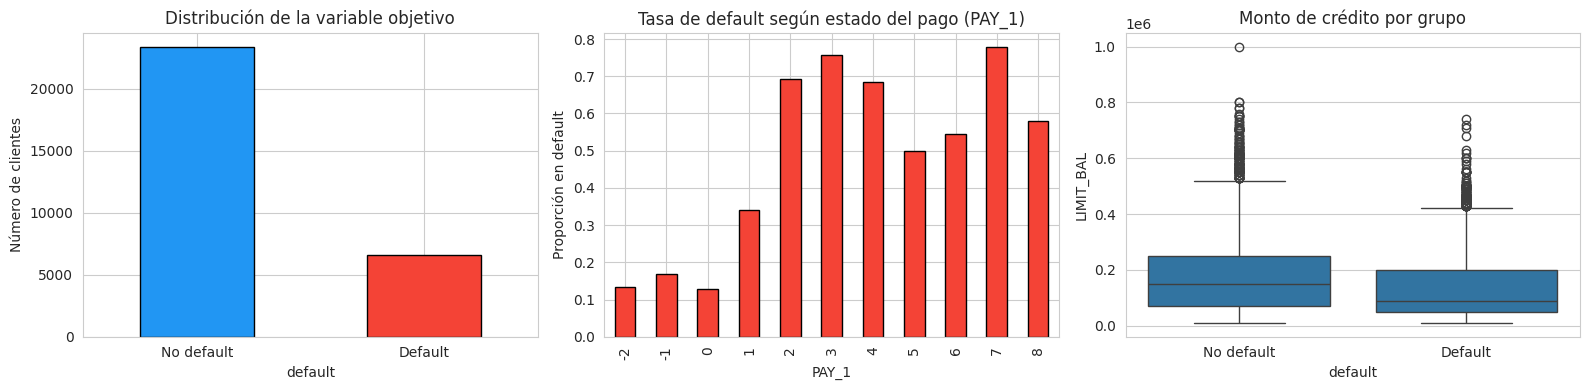

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución del objetivo
conteo.rename({0: 'No default', 1: 'Default'}).plot(
    kind='bar', ax=axes[0], color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Distribución de la variable objetivo')
axes[0].set_ylabel('Número de clientes')
axes[0].tick_params(axis='x', rotation=0)

# Tasa de default según el estado del último pago
df.groupby('PAY_1')['default'].mean().plot(
    kind='bar', ax=axes[1], color='#F44336', edgecolor='black')
axes[1].set_title('Tasa de default según estado del pago (PAY_1)')
axes[1].set_ylabel('Proporción en default')

# Monto de crédito según incumplimiento
sns.boxplot(data=df, x='default', y='LIMIT_BAL', ax=axes[2])
axes[2].set_title('Monto de crédito por grupo')
axes[2].set_xticklabels(['No default', 'Default'])
plt.tight_layout()
plt.show()


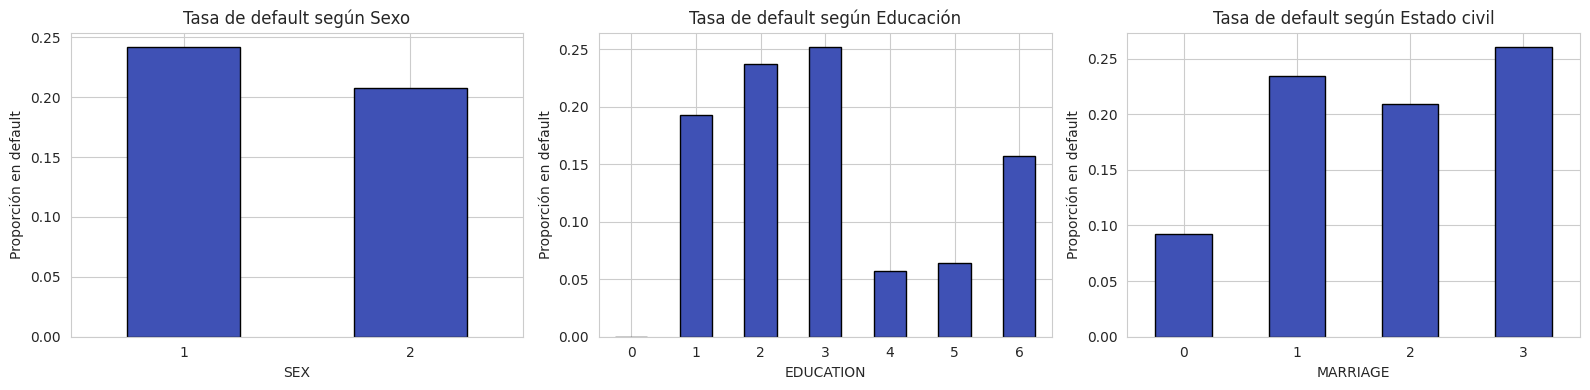

In [ ]:
# Tasa de default según variables demográficas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, titulo in zip(axes,
                           ['SEX', 'EDUCATION', 'MARRIAGE'],
                           ['Sexo', 'Educación', 'Estado civil']):
    df.groupby(col)['default'].mean().plot(kind='bar', ax=ax, color='#3F51B5', edgecolor='black')
    ax.set_title(f'Tasa de default según {titulo}')
    ax.set_ylabel('Proporción en default')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


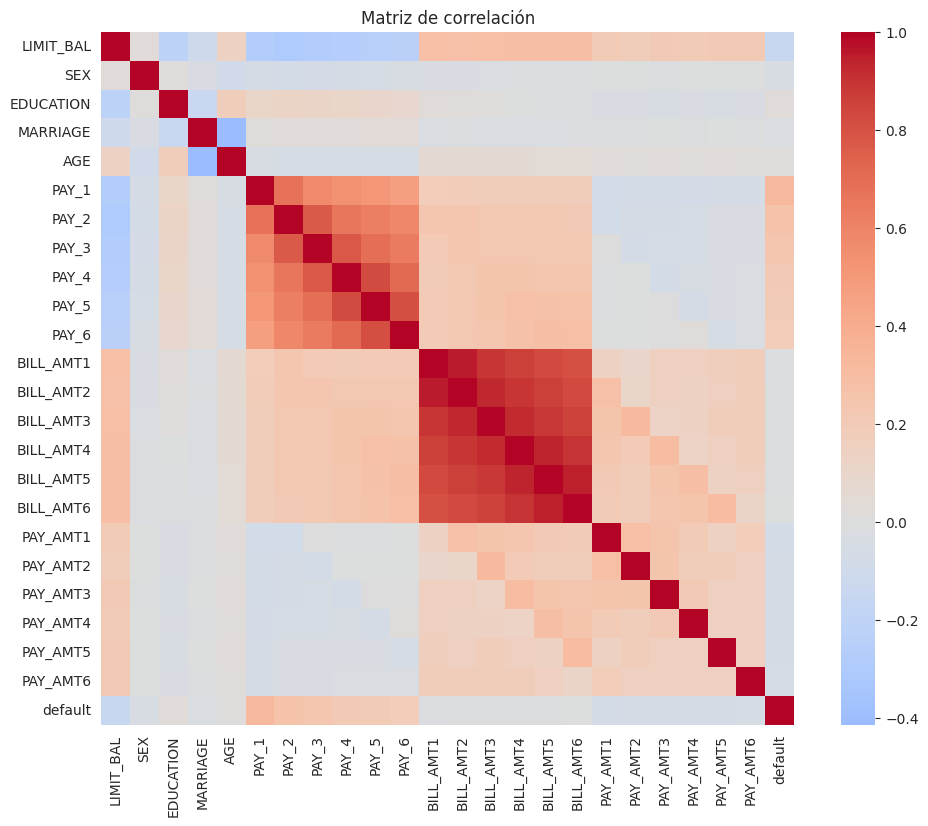

In [ ]:
# Correlación entre las variables numéricas
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0, square=True)
plt.title('Matriz de correlación')
plt.show()


La variable con mayor asociación al default es el historial de pagos reciente (PAY_1 a PAY_6): a mayor atraso, mayor tasa de incumplimiento. Los montos de estado de cuenta (BILL_AMT) están muy correlacionados entre sí, lo que sugiere redundancia entre esos meses.


### 2.4 Valores atípicos

Se aplica el método IQR (Tukey), sobre las variables monetarias con mayor dispersión.


In [ ]:
# Deteccion de atipicos con el metodo IQR (Tukey)
def fn_atipicos_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = (serie < limite_inf) | (serie > limite_sup)
    return atipicos.sum(), atipicos.mean(), limite_inf, limite_sup

for col in ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']:
    n, pct, lo, hi = fn_atipicos_iqr(df[col])
    print(f'{col}: limites=[{lo:,.0f}, {hi:,.0f}]  atipicos={n} ({pct:.1%})')


LIMIT_BAL: limites=[-235,000, 525,000]  atipicos=167 (0.6%)
BILL_AMT1: limites=[-91,740, 162,389]  atipicos=2400 (8.0%)
PAY_AMT1: limites=[-5,009, 11,015]  atipicos=2745 (9.2%)


Entre 0.6% y 9.2% de los clientes quedan marcados como atípicos según este criterio, principalmente en BILL_AMT y PAY_AMT. No son errores: son clientes con montos de crédito, facturación o pago más altos que el resto, algo esperable en una cartera real de tarjetas de crédito. Eliminarlos o recortarlos sesgaría el modelo justo contra los clientes de mayor movimiento, que son relevantes para el riesgo crediticio. **Se mantienen sin modificar.**


In [ ]:
# Revisar valores negativos en los montos de estado de cuenta
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
print('Filas con BILL_AMT negativo por mes:')
print((df[bill_cols] < 0).sum())


Filas con BILL_AMT negativo por mes:
BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688
dtype: int64


Alrededor de 2% de los clientes por mes presenta un estado de cuenta negativo.  Quiere decir que el cliente pagó de más el mes anterior y quedó con saldo a favor. **Se mantiene sin modificar.**


## 3. Preprocesamiento e ingeniería de atributos

Antes de limpiar o codificar una variable conviene entender qué contiene, porque no todas requieren el mismo tratamiento.


### 3.1 Revisión de las variables de historial de pago (PAY_1...PAY_6)

El paper documenta esta escala solo entre -1 (al día) y 9 (nueve meses o más de atraso). Antes de usarla tal cual, se revisa si los datos reales respetan esa escala.


In [ ]:
# Valores observados en PAY_1 (el mismo patron se repite en PAY_2...PAY_6)
df['PAY_1'].value_counts().sort_index()


,count
PAY_1,
-2,2759
-1,5686
0,14737
1,3688
2,2667
3,322
4,76
5,26
6,11


Aparecen los códigos -2 y 0, que el paper no documenta. De hecho, 0 es el valor más frecuente de toda la variable. Antes de decidir qué hacer, se revisa cómo se relacionan estos códigos con el default.


In [ ]:
# Tasa de default segun el codigo de PAY_1
df.groupby('PAY_1')['default'].mean()


,default
PAY_1,
-2,0.1323
-1,0.1678
0,0.1281
1,0.3395
2,0.6914
3,0.7578
4,0.6842
5,0.5000
6,0.5455


Los códigos -2, -1 y 0 tienen una tasa de default parecida (13%-17%): en la práctica se comportan como una sola categoría de "sin atraso relevante". El salto ocurre recién desde 1 en adelante (34%, 69%, 76%...). Se decide mantener la codificación ordinal tal cual, igual que el paper, porque los modelos de árbol (CART, Random Forest) encuentran este punto de quiebre por sí solos al elegir sus cortes. La Regresión Logística, en cambio, asume que cada unidad de PAY_1 aporta el mismo efecto, lo que no calza con este patrón; se retoma esta idea en la Sección 7 al comparar los modelos.


### 3.2 Limpieza de EDUCATION y MARRIAGE

A diferencia de PAY, estas son variables nominales (categorías sin orden), por lo que sus códigos no documentados sí se agrupan antes de codificar:

- EDUCATION contiene los códigos 0, 5 y 6, no descritos en el diccionario; se agrupan en la categoría 4 ("otros").
- MARRIAGE contiene el código 0, que se agrupa en 3 ("otros").
- SEX, EDUCATION y MARRIAGE se codifican como variables dummy.


In [ ]:
# Limpieza de categorías no documentadas
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

# Codificación de variables categóricas nominales
categoricas = ['SEX', 'EDUCATION', 'MARRIAGE']
df_enc = pd.get_dummies(df, columns=categoricas, drop_first=True)

X = df_enc.drop(columns='default').astype(float)
y = df_enc['default'].astype(int)
print('Dimensiones de X tras la codificación:', X.shape)


Dimensiones de X tras la codificación: (30000, 26)


### 3.3 Partición y escalamiento


In [ ]:
# Partición en entrenamiento y prueba, estratificada por el objetivo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)

# Estandarización (se ajusta solo con entrenamiento)
escala = StandardScaler()
X_train_std = escala.fit_transform(X_train)
X_test_std = escala.transform(X_test)

print('Entrenamiento:', X_train.shape[0], 'clientes')
print('Prueba       :', X_test.shape[0], 'clientes')


Entrenamiento: 24000 clientes
Prueba       : 6000 clientes


**Nota sobre el desbalance.** El foco del paper es la calidad de la *probabilidad* estimada (método SSM). Técnicas de rebalanceo como SMOTE o `class_weight='balanced' mejoran el recall pero distorsionan las probabilidades (las alejan de la tasa real de default), lo que perjudicaría el análisis de calibración. Por eso los modelos se entrenan sobre los datos originales, tal como en el paper.


## 4. Modelos del paper

El paper compara seis técnicas. Siguiendo la Sección 5.1 de la pauta (que permite un subconjunto representativo), se implementan tres: dos modelos clásicos (regresión logística y árbol de clasificación) y el modelo que el paper destaca como el mejor, las redes neuronales artificiales.

Todos los modelos se afinan con GridSearchCV y validación cruzada estratificada de 5 particiones. Se usa scoring='roc_auc' en vez de 'accuracy': como el propio paper argumenta (Sección 3.1), con solo 22% de clientes en default la tasa de acierto es poco sensible, por lo que se optimiza directamente la capacidad de ordenar clientes por riesgo (equivalente al *area ratio* del paper).


### 4.1 Regresión logística (LR)

Modelo lineal clásico de clasificación. Entrega directamente una probabilidad y sirve como línea base interpretable. Se afina el parámetro de regularización C por validación cruzada; se aumenta max_iter para asegurar la convergencia sobre los datos estandarizados.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=0),
    param_grid={'C': [0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_std, y_train)
lr = grid_lr.best_estimator_
print('Mejores hiperparámetros LR:', grid_lr.best_params_)


Mejores hiperparámetros LR: {'C': 100}


### 4.2 Árbol de clasificación (CART)

Equivalente a los *classification trees* del paper. El criterio de partición, la profundidad y el tamaño mínimo de hoja se eligen con validación cruzada, para controlar el sobreajuste.


In [ ]:
grid_cart = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid={'criterion': ['gini', 'entropy'],
                'max_depth': [3, 4, 5, 6, 8],
                'min_samples_leaf': [20, 50, 100]},
    cv=cv, scoring='roc_auc', n_jobs=-1)
grid_cart.fit(X_train, y_train)
cart = grid_cart.best_estimator_
print('Mejores hiperparámetros CART:', grid_cart.best_params_)


Mejores hiperparámetros CART: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 100}


**Importancia de variables.** Se revisa qué variables usa más el árbol para tomar decisiones, y se compara con lo observado en la matriz de correlación de la Sección 2.


In [ ]:
# Importancia de variables del arbol
importancia_cart = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': cart.feature_importances_
}).sort_values('Importancia', ascending=False)
importancia_cart.head(10)


,Variable,Importancia
2,PAY_1,0.6357
3,PAY_2,0.1354
16,PAY_AMT3,0.0468
8,BILL_AMT1,0.0317
0,LIMIT_BAL,0.0295
6,PAY_5,0.0229
7,PAY_6,0.0202
17,PAY_AMT4,0.0105
9,BILL_AMT2,0.0098
19,PAY_AMT6,0.0085


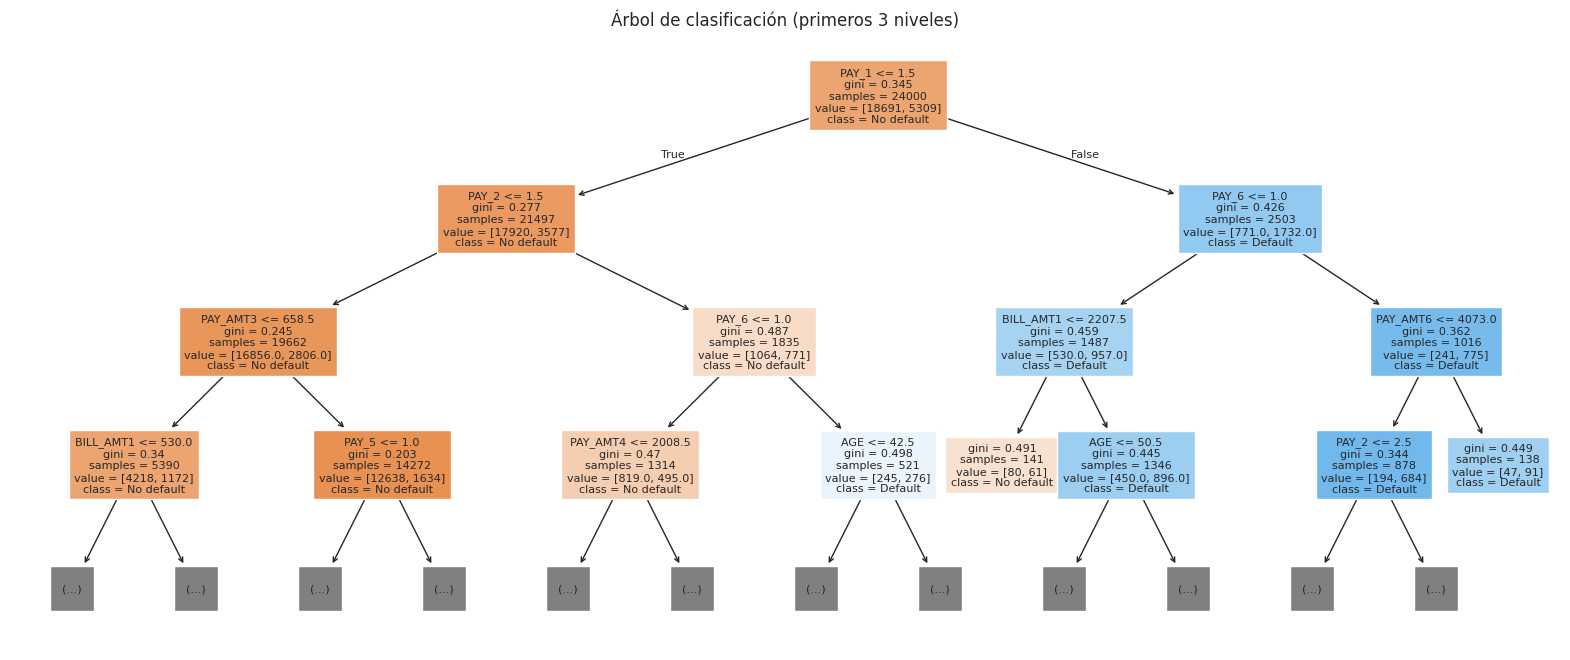

In [ ]:
# Visualizar el arbol (primeros niveles, para legibilidad)
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(cart, filled=True, max_depth=3, fontsize=8,
          feature_names=X.columns.tolist(),
          class_names=['No default', 'Default'])
plt.title('Árbol de clasificación (primeros 3 niveles)')
plt.show()


PAY_1 concentra el 63.6% de la importancia del árbol y PAY_2 otro 13.5%: juntas explican más de tres cuartos de las decisiones del modelo, confirmando lo observado en la matriz de correlación y en la Sección 3.1. El árbol usa exactamente PAY_1 <= 1.5 como primera pregunta: separa a los clientes con códigos -2, -1, 0 o 1 (mayoritariamente sin default) de los que tienen código 2 o más (mayoritariamente en default). Es el mismo quiebre detectado manualmente al revisar la tasa de default por código en la Sección 3.1, esta vez encontrado de forma automática por el algoritmo.


### 4.3 Redes neuronales artificiales (ANN)

Es el modelo que el paper concluye como el mejor. **Esta técnica no se vio en el curso**; se incorpora porque replicar el hallazgo central del paper (que la ANN es la única que calibra bien la probabilidad de default) requiere implementarla. Se usa un perceptrón multicapa (MLPClassifier de scikit-learn), una red feed-forward entrenada con retropropagación, igual que en el paper. El número de neuronas ocultas y la regularización (alpha) se afinan con la misma lógica de GridSearchCV usada en el resto del cuaderno; se agrega parada temprana (early_stopping) para evitar el sobreajuste. Se entrena con los datos estandarizados.


In [ ]:
grid_ann = GridSearchCV(
    MLPClassifier(activation='relu', max_iter=300, early_stopping=True,
                  validation_fraction=0.1, random_state=0),
    param_grid={'hidden_layer_sizes': [(16,), (32,), (16, 8)],
                'alpha': [0.0001, 0.001]},
    cv=cv, scoring='roc_auc', n_jobs=-1)
grid_ann.fit(X_train_std, y_train)
ann = grid_ann.best_estimator_
print('Mejores hiperparámetros ANN:', grid_ann.best_params_)


Mejores hiperparámetros ANN: {'alpha': 0.001, 'hidden_layer_sizes': (32,)}


## 5. Modelo adicional propuesto: Random Forest

Se propone **Random Forest**, un ensamble de árboles de decisión no considerado por los autores. La justificación:

- Captura efectos no lineales e interacciones entre variables, igual que la ANN, pero con menor riesgo de sobreajuste gracias al promedio de muchos árboles.
- Es un *benchmark* estándar en scoring crediticio y suele rendir muy bien en datos tabulares.
- No requiere escalamiento y entrega una probabilidad estable (proporción de votos), útil para el análisis de calibración SSM.

Al igual que los modelos anteriores, sus hiperparámetros (número de árboles, profundidad y tamaño mínimo de hoja) se afinan con GridSearchCV.


In [ ]:
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=0, n_jobs=-1),
    param_grid={'n_estimators': [200, 300],
                'max_depth': [6, 8, 10],
                'min_samples_leaf': [30, 50, 100]},
    cv=cv, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)
rf = grid_rf.best_estimator_
print('Mejores hiperparámetros Random Forest:', grid_rf.best_params_)


Mejores hiperparámetros Random Forest: {'max_depth': 10, 'min_samples_leaf': 50, 'n_estimators': 200}


**Importancia de variables.** Igual que con el árbol, se revisa qué variables aporta más Random Forest.


Variable  Importancia
   PAY_1       0.3411
   PAY_2       0.1457
   PAY_3       0.0825
   PAY_4       0.0749
   PAY_5       0.0541
   PAY_6       0.0413


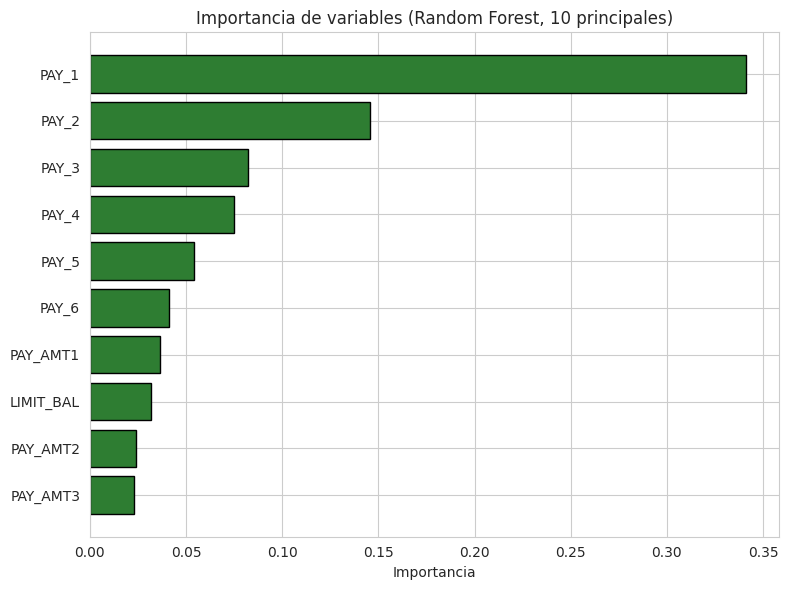

In [ ]:
# Importancia de variables de Random Forest
importancia_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)
print(importancia_rf.head(6).to_string(index=False))

plt.figure(figsize=(8, 6))
plot_data = importancia_rf.sort_values('Importancia', ascending=True).tail(10)
plt.barh(plot_data['Variable'], plot_data['Importancia'], color='#2E7D32', edgecolor='black')
plt.title('Importancia de variables (Random Forest, 10 principales)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()


Random Forest reparte la importancia entre las seis variables PAY (PAY_1 = 34.1%, PAY_2 = 14.6%, y las restantes entre 4% y 8% cada una), que en conjunto explican tres cuartos de la importancia total. A diferencia del árbol individual, que se apoya casi todo en PAY_1 y PAY_2, el bosque aprovecha también PAY_3 a PAY_6 al promediar muchos árboles distintos. El patrón es consistente con el del árbol y con la matriz de correlación: dos modelos entrenados de forma independiente llegan a la misma conclusión sobre qué variables importan.


## 6. Comparación de resultados

Se evalúan todos los modelos sobre el conjunto de prueba con las métricas del paper y otras equivalentes:

- **Tasa de error** y **Accuracy** (usadas en la Tabla 1 del paper).
- **Area ratio**, definida en el paper a partir del lift chart. Es equivalente al coeficiente de Gini, que se obtiene como 2·AUC − 1; se reporta también el **AUC**.
- **Precision, Recall y F1**, métricas de clasificación estándar vistas en clase, pertinentes por el desbalance.
- **Sorting Smoothing Method (SSM)**: réplica del aporte central del paper (Tabla 2). Se estima la probabilidad real de default y se ajusta la regresión Y = A + BX entre probabilidad real y predicha. El mejor modelo tiene R² cercano a 1, intercepto A cercano a 0 y pendiente B cercana a 1.

Precision, Recall y F1 dependen del umbral de decisión (0.5 por defecto); a diferencia del AUC y el area ratio, que son independientes del umbral, tal como argumentan los propios autores al preferir el area ratio sobre el error rate.


In [ ]:
# Reunir los modelos con el conjunto de prueba que corresponde a cada uno
modelos = {
    'Regresión Logística': (lr, X_test_std),
    'Árbol (CART)': (cart, X_test),
    'Redes Neuronales (ANN)': (ann, X_test_std),
    'Random Forest': (rf, X_test),
}
probas = {n: m.predict_proba(Xt)[:, 1] for n, (m, Xt) in modelos.items()}
preds = {n: m.predict(Xt) for n, (m, Xt) in modelos.items()}


In [ ]:
def area_ratio(y_true, y_score):
    # Equivale al 'area ratio' del lift chart del paper (coeficiente de Gini)
    return 2 * roc_auc_score(y_true, y_score) - 1


def sorting_smoothing_method(y_true, y_score, n=50):
    # Ordena por probabilidad predicha y estima la probabilidad real
    # como el promedio del objetivo en una ventana de 2n+1 vecinos
    orden = np.argsort(y_score)
    y_ord = np.asarray(y_true)[orden]
    p_pred = np.asarray(y_score)[orden]
    total = len(y_ord)
    p_real = np.full(total, np.nan)
    for i in range(n, total - n):
        p_real[i] = y_ord[i - n:i + n + 1].mean()
    ok = ~np.isnan(p_real)
    return p_pred[ok], p_real[ok]


def regresion_ssm(p_pred, p_real):
    # Ajusta Y = A + B X entre probabilidad real (Y) y predicha (X)
    Xr = p_pred.reshape(-1, 1)
    reg = LinearRegression().fit(Xr, p_real)
    return reg.coef_[0], reg.intercept_, reg.score(Xr, p_real)


### 6.1 Verificación de sobreajuste (comparable con la Tabla 1 del paper)

La Tabla 1 del paper reporta el error y el area ratio tanto en entrenamiento como en validación, para verificar que los modelos generalizan. Se replica esa comparación.


In [ ]:
# Predicciones sobre el set de entrenamiento, para comparar con el de prueba
modelos_train = {
    'Regresión Logística': (lr, X_train_std),
    'Árbol (CART)': (cart, X_train),
    'Redes Neuronales (ANN)': (ann, X_train_std),
    'Random Forest': (rf, X_train),
}
preds_train = {n: m.predict(Xt) for n, (m, Xt) in modelos_train.items()}
probas_train = {n: m.predict_proba(Xt)[:, 1] for n, (m, Xt) in modelos_train.items()}

filas_tabla1 = []
for nombre in modelos:
    filas_tabla1.append({
        'Modelo': nombre,
        'Error rate (train)': 1 - accuracy_score(y_train, preds_train[nombre]),
        'Error rate (test)': 1 - accuracy_score(y_test, preds[nombre]),
        'Area ratio (train)': area_ratio(y_train, probas_train[nombre]),
        'Area ratio (test)': area_ratio(y_test, probas[nombre]),
    })
tabla1_estilo = pd.DataFrame(filas_tabla1).set_index('Modelo')
tabla1_estilo


,Error rate (train),Error rate (test),Area ratio (train),Area ratio (test)
Modelo,,,,
Regresión Logística,0.1893,0.1872,0.4579,0.4339
Árbol (CART),0.1766,0.1803,0.5760,0.5246
Redes Neuronales (ANN),0.1777,0.1815,0.5763,0.5306
Random Forest,0.1753,0.1767,0.6261,0.5621


El error de entrenamiento y de prueba son casi idénticos en los cuatro modelos (diferencias de 0.001 a 0.004), sin señales de sobreajuste según esa métrica. El area ratio sí muestra una brecha moderada entre entrenamiento y prueba en todos los modelos (entre 0.02 y 0.06), esperable porque el conjunto de entrenamiento es el que cada modelo ya vio; ninguna brecha es lo bastante grande como para sugerir sobreajuste relevante, consistentes con la regularización aplicada en cada GridSearchCV.


### 6.2 Métricas de clasificación y calibración (conjunto de prueba)


In [ ]:
# Construir la tabla comparativa
filas = []
for nombre, (mod, Xte) in modelos.items():
    yp, ps = preds[nombre], probas[nombre]
    p_pred, p_real = sorting_smoothing_method(y_test.values, ps, n=50)
    b, a, r2 = regresion_ssm(p_pred, p_real)
    filas.append({
        'Modelo': nombre,
        'Error rate': 1 - accuracy_score(y_test, yp),
        'Accuracy': accuracy_score(y_test, yp),
        'Precisión': precision_score(y_test, yp),
        'Recall': recall_score(y_test, yp),
        'F1': f1_score(y_test, yp),
        'AUC': roc_auc_score(y_test, ps),
        'Area ratio': area_ratio(y_test, ps),
        'SSM R2': r2,
        'SSM A': a,
        'SSM B': b,
    })
resultados = pd.DataFrame(filas).set_index('Modelo')
resultados


,Error rate,Accuracy,Precisión,Recall,F1,AUC,Area ratio,SSM R2,SSM A,SSM B
Modelo,,,,,,,,,,
Regresión Logística,0.1872,0.8128,0.7329,0.2419,0.3637,0.7170,0.4339,0.8043,-0.0310,1.1419
Árbol (CART),0.1803,0.8197,0.6723,0.3602,0.4691,0.7623,0.5246,0.9351,0.0135,0.9389
Redes Neuronales (ANN),0.1815,0.8185,0.6667,0.3587,0.4664,0.7653,0.5306,0.9525,-0.0058,1.0124
Random Forest,0.1767,0.8233,0.6921,0.3625,0.4758,0.7810,0.5621,0.9670,-0.0233,1.1083


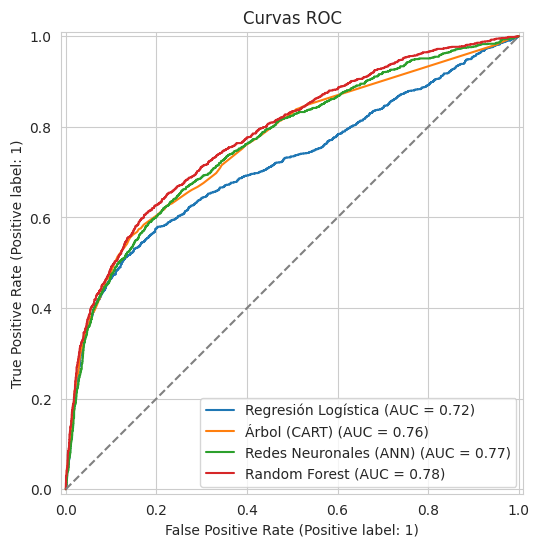

In [ ]:
# Curvas ROC de todos los modelos
fig, ax = plt.subplots(figsize=(7, 6))
for nombre in modelos:
    RocCurveDisplay.from_predictions(y_test, probas[nombre], name=nombre, ax=ax)
ax.plot([0, 1], [0, 1], '--', color='gray')
ax.set_title('Curvas ROC')
plt.show()


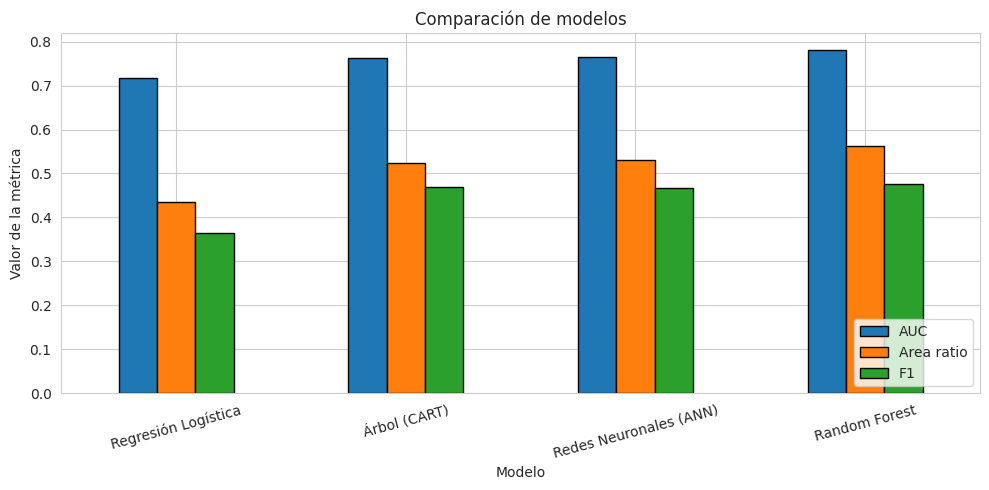

In [ ]:
# Comparación gráfica de métricas clave
resultados[['AUC', 'Area ratio', 'F1']].plot(
    kind='bar', figsize=(10, 5), edgecolor='black')
plt.title('Comparación de modelos')
plt.ylabel('Valor de la métrica')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 6.3 Réplica del análisis de probabilidad (Sorting Smoothing Method)

Los siguientes diagramas de dispersión replican las Figuras 8 a 13 del paper: en el eje horizontal, la probabilidad predicha; en el vertical, la probabilidad real estimada con el SSM. La recta roja es la regresión ajustada y la línea gris punteada es la diagonal ideal (Y = X). Cuanto más se pega la nube a la diagonal y mayor es el R², mejor calibrada está la probabilidad del modelo.


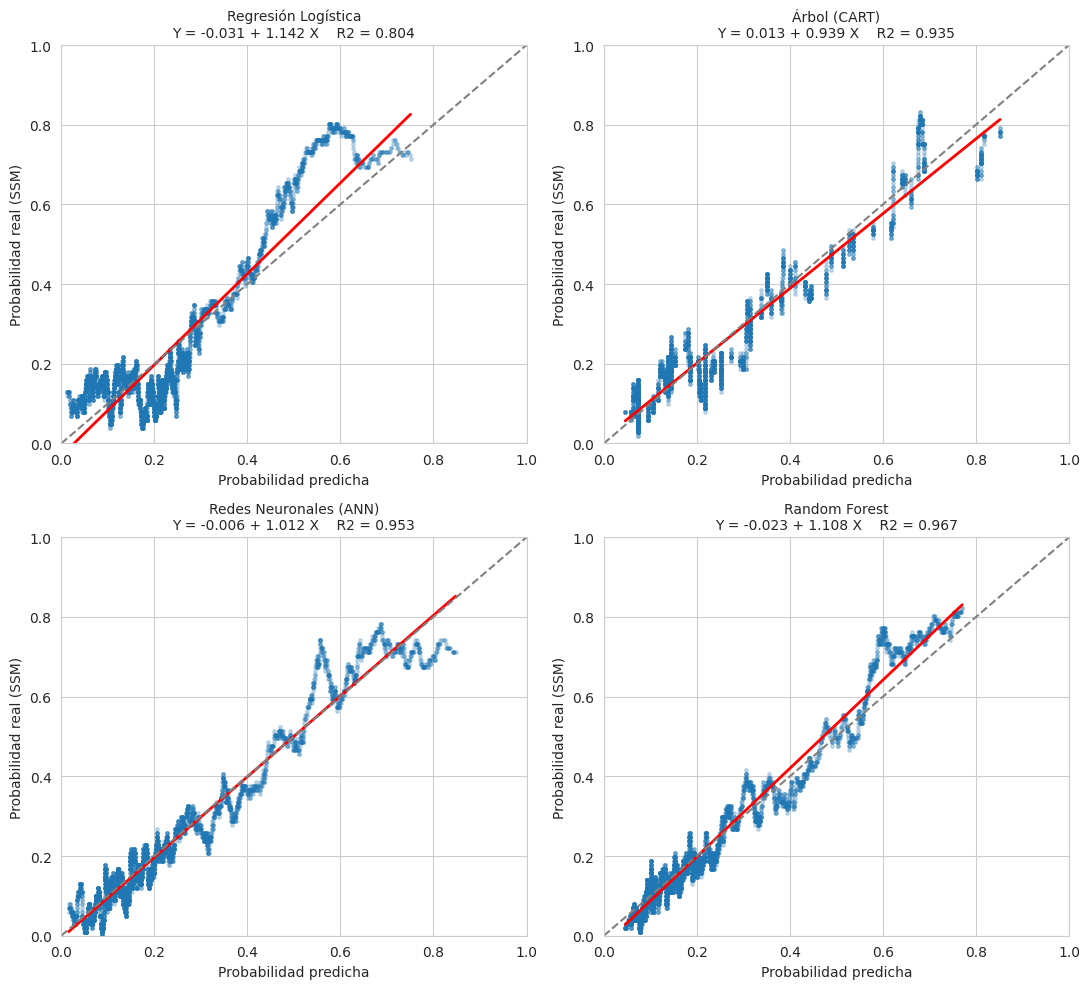

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, nombre in zip(axes.ravel(), modelos):
    ps = probas[nombre]
    p_pred, p_real = sorting_smoothing_method(y_test.values, ps, n=50)
    b, a, r2 = regresion_ssm(p_pred, p_real)
    ax.scatter(p_pred, p_real, s=6, alpha=0.25, color='#1f77b4')
    xx = np.linspace(p_pred.min(), p_pred.max(), 100)
    ax.plot(xx, a + b * xx, color='red', linewidth=2)
    ax.plot([0, 1], [0, 1], '--', color='gray')
    ax.set_title(f"{nombre}\nY = {a:.3f} + {b:.3f} X    R2 = {r2:.3f}", fontsize=10)
    ax.set_xlabel('Probabilidad predicha')
    ax.set_ylabel('Probabilidad real (SSM)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
# Tabla resumen del SSM (comparable con la Tabla 2 del paper)
resumen_ssm = resultados[['SSM B', 'SSM A', 'SSM R2']].copy()
resumen_ssm.columns = ['Pendiente (B)', 'Intercepto (A)', 'R2']
resumen_ssm


,Pendiente (B),Intercepto (A),R2
Modelo,,,
Regresión Logística,1.1419,-0.0310,0.8043
Árbol (CART),0.9389,0.0135,0.9351
Redes Neuronales (ANN),1.0124,-0.0058,0.9525
Random Forest,1.1083,-0.0233,0.9670


Para referencia, la Tabla 2 del paper original reporta los siguientes valores (para sus seis modelos):

| Método | Pendiente (B) | Intercepto (A) | R² |
|---|---|---|---|
| KNN | 0.770 | 0.0522 | 0.876 |
| Regresión logística | 1.233 | -0.0523 | 0.794 |
| Análisis discriminante | 0.837 | -0.1530 | 0.659 |
| Naive Bayes | 0.502 | 0.0901 | 0.899 |
| Redes neuronales | 0.998 | 0.0145 | 0.965 |
| Árbol de clasificación | 1.111 | -0.0276 | 0.278 |


## 7. Discusión y conclusiones

### ¿Se replican los resultados del paper?

Sí, al menos cualitativamente. La *area ratio* de validación que obtuvimos sigue el mismo orden que la Tabla 1 del paper entre los tres modelos originales: árbol (0.525) y ANN (0.531) por sobre regresión logística (0.434), muy en línea con los valores del paper (ANN 0.54, árbol 0.536, LR 0.44). La ANN es, junto al árbol, la de mejor discriminación entre los modelos del paper (AUC 0.765), como concluyen los autores.

En la réplica del Sorting Smoothing Method, la ANN es la mejor calibrada de los tres modelos originales: intercepto A = -0.006 (muy cercano a 0) y pendiente B = 1.012 (muy cercana a 1), con R² = 0.953, resultado aún más parecido al ideal que el propio paper (A = 0.0145, B = 0.998, R² = 0.965). Esto reproduce el hallazgo central del paper: la probabilidad predicha por la ANN representa fielmente la probabilidad real de default.

La principal diferencia respecto al paper aparece en el árbol de clasificación. En el paper su R² del SSM es muy bajo (0.278) porque un árbol sin podar entrega probabilidades escalonadas y mal calibradas. Nuestro árbol, regularizado con validación cruzada (criterio gini, max_depth = 8, min_samples_leaf = 100), quedó mucho mejor calibrado (R² = 0.936). La diferencia se explica por la regularización: el paper no menciona haber podado sus árboles.

### El modelo adicional (Random Forest)

Random Forest fue el mejor en todas las métricas de clasificación: mayor AUC (0.781), mayor area ratio (0.562), mejor F1 (0.476) y el mayor R² del SSM (0.967). Sin embargo, bajo el criterio estricto del paper (A cercano a 0 y B cercano a 1), la ANN queda levemente mejor calibrada en nivel: la pendiente de Random Forest (B = 1.108) se aleja algo más de 1 que la de la ANN (B = 1.012), señal de que Random Forest tiende a sobreestimar un poco las probabilidades altas aunque su ajuste sea más ceñido (R² más alto).

### ¿Por qué rinde peor Regresión Logística?

La importancia de variables (Secciones 4.2 y 5) confirma que PAY_1 y el resto de las variables de historial de pago concentran la mayor parte del poder predictivo, tal como ya sugería la matriz de correlación de la Sección 2. Como se observó en la Sección 3.1, la relación entre estas variables y el default no es lineal: los códigos -2, -1 y 0 tienen tasas de default parecidas, y el riesgo salta recién desde el código 1 en adelante. Esto perjudica en particular a la **Regresión Logística**, que asume un efecto constante por cada unidad de PAY_1, cuando en realidad el riesgo se mantiene parejo hasta ese punto y luego salta bruscamente.

### ¿Cuál es el mejor modelo?

Tomando en cuenta todas las métricas obtenidas, **Random Forest es el mejor modelo para este problema**: domina en poder de discriminación (AUC y area ratio), en F1 y en el ajuste global del SSM (R²), y es robusto y estable sin necesitar escalamiento. Las redes neuronales quedan muy cerca y son las mejores por el criterio de calibración pura (pendiente e intercepto casi ideales), lo que confirma cualitativamente la conclusión del paper: la ANN es la mejor entre las seis técnicas originales. Random Forest, la ANN y el árbol —los tres modelos capaces de capturar el quiebre no lineal de PAY_1— superan con claridad a Regresión Logística, que muestra un recall bajo (0.24) y peor area ratio, por la razón específica descrita arriba.

Desde la perspectiva de gestión de riesgo del paper, la lección se mantiene: métodos capaces de capturar relaciones no lineales (ANN y ensambles de árboles) estiman mejor la probabilidad real de default que los modelos que no lo hacen.

### Aprendizaje metodológico

El análisis SSM distingue algo que el AUC no captura: dos modelos con AUC parecido pueden calibrar de forma muy distinta, y un modelo puede tener un R² del SSM más alto (ajuste más ceñido a su propia recta) sin que esa recta sea la más cercana a la diagonal ideal Y = X. En riesgo crediticio la calibración de la probabilidad es tan importante como la capacidad de ordenar clientes por riesgo, y por eso conviene reportar ambas dimensiones.

### Verificación de sobreajuste

La comparación train/test de la Sección 6.1 no muestra señales de sobreajuste relevantes: el error de entrenamiento y de prueba son casi idénticos en los cuatro modelos, y el area ratio muestra brechas moderadas (0.02 a 0.06) entre entrenamiento y prueba, explicadas por la regularización aplicada en cada GridSearchCV y no por sobreajuste.

### Limitaciones

- El conjunto público del UCI tiene 30.000 observaciones, mientras que el paper usa 25.000; la muestra no es idéntica.
- El paper no especifica la arquitectura exacta de la ANN ni la partición entrenamiento/validación; nuestras grillas de hiperparámetros y el split 80/20 difieren de las suyas.
- No se replicó el lift chart original (Figuras 2-7), sino su equivalente formal (coeficiente de Gini / area ratio) junto con el AUC y la curva ROC.
- Por tiempo de cómputo, las grillas de GridSearchCV se mantuvieron acotadas; grillas más finas podrían cambiar levemente los hiperparámetros óptimos.
- Los valores pueden variar levemente según la versión de las librerías y la semilla aleatoria usada en el entrenamiento de la red neuronal y el random forest.
